In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, precision_recall_curve, average_precision_score,
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

# Укажите название вашего датасета (из списка)
DATASET_NAME = "ecoli"  # ИЗМЕНИТЕ НА НУЖНЫЙ

print(f"Работа с датасетом: {DATASET_NAME}")

Работа с датасетом: ecoli


Для некоторых датасетов может не работать fetch_openml(name=...) — тогда нужно будет найти data_id на OpenML и заменить на число:

1. (1 балл) Загрузите предложенный вам датасет с помощью функции `sklearn.datasets.fetch_openml`. Выведите текстовое описание загруженного датасета. Определите какая бизнес-задача ставится. Переведите бизнес-задачу в задачу машинного обучения.

In [ ]:
def load_and_describe(dataset_name):
    try:
        data = fetch_openml(data_id=dataset_name, as_frame=True, parser='auto')
    except:
        data = fetch_openml(name=dataset_name, as_frame=True, parser='auto')

    df = data.frame
    print("=== ОПИСАНИЕ ДАТАСЕТА ===")
    print(f"Название: {data.details.get('name', 'Неизвестно')}")
    print(f"Описание: {data.details.get('description', 'Нет описания')[:500]}...")
    print(f"Количество строк: {df.shape[0]}, столбцов: {df.shape[1]}")
    print(f"Целевой признак: {data.target_names if hasattr(data, 'target_names') else 'unknown'}")

    target_col = data.target_names[0] if hasattr(data, 'target_names') else 'class'
    unique_targets = df[target_col].nunique()

    if unique_targets <= 10:
        task_type = "классификация"
        n_classes = unique_targets
    else:
        task_type = "регрессия"
        n_classes = None

    print(f"\n=== БИЗНЕС-ЗАДАЧА ===")
    print(f"На основе описания датасета бизнес-задача: предсказание значения '{target_col}'")
    print(f"Перевод в задачу МО: это задача {task_type} с {unique_targets} уникальными значениями целевой переменной.")

    return data, df, task_type, target_col

data, df, TASK_TYPE, TARGET_COL = load_and_describe(DATASET_NAME)
print(f"\nОпределенный тип задачи: {TASK_TYPE}")

# ВАШ ВЫВОД:
# Напишите здесь свои выводы: какой датасет получили, какие признаки,
# какая бизнес-задача, почему это классификация или регрессия.

=== ОПИСАНИЕ ДАТАСЕТА ===
Название: ecoli
Описание: Нет описания...
Количество строк: 336, столбцов: 8
Целевой признак: ['class']

=== БИЗНЕС-ЗАДАЧА ===
На основе описания датасета бизнес-задача: предсказание значения 'class'
Перевод в задачу МО: это задача классификация с 8 уникальными значениями целевой переменной.

Определенный тип задачи: классификация


Датасет Ecoli решает задачу предсказания локализации белка по его характеристикам. Это задача многоклассовой классификации (8 классов). Особенность: возможен дисбаланс классов, что повлияет на выбор метрик и стратегию обучения.

2. (1 балл) Проведите предварительный анализ датасета.  Выведите основную статистическую информацию о данных. Проверьте дисбаланс целевого признака.

СТАТИСТИЧЕСКАЯ ИНФОРМАЦИЯ
Типы данных:
mcg       float64
gvh       float64
lip       float64
chg       float64
aac       float64
alm1      float64
alm2      float64
class    category
dtype: object

Основные статистики:
              mcg         gvh         lip         chg         aac        alm1  \
count  336.000000  336.000000  336.000000  336.000000  336.000000  336.000000   
mean     0.500060    0.500000    0.495476    0.501488    0.500030    0.500179   
std      0.194634    0.148157    0.088495    0.027277    0.122376    0.215751   
min      0.000000    0.160000    0.480000    0.500000    0.000000    0.030000   
25%      0.340000    0.400000    0.480000    0.500000    0.420000    0.330000   
50%      0.500000    0.470000    0.480000    0.500000    0.495000    0.455000   
75%      0.662500    0.570000    0.480000    0.500000    0.570000    0.710000   
max      0.890000    1.000000    1.000000    1.000000    0.880000    1.000000   

             alm2  
count  336.000000  
mean     0.

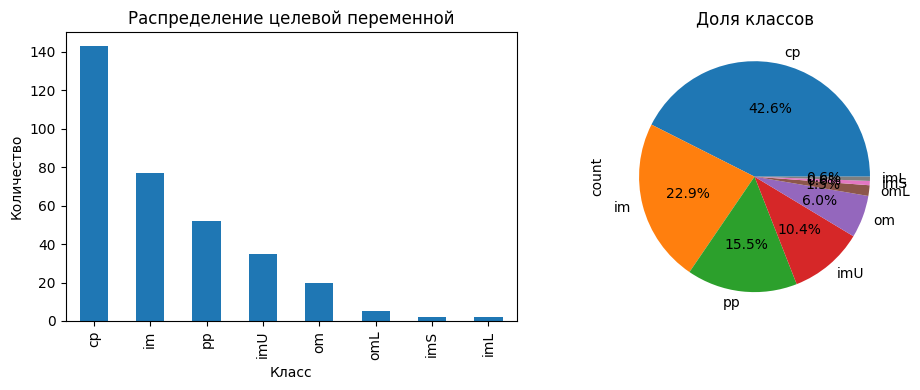

In [ ]:
def exploratory_analysis(df, target_col, task_type):
    print("СТАТИСТИЧЕСКАЯ ИНФОРМАЦИЯ")
    print(f"Типы данных:\n{df.dtypes}")
    print(f"\nОсновные статистики:\n{df.describe()}")

    print(f"\nПРОВЕРКА ДИСБАЛАНСА ЦЕЛЕВОГО ПРИЗНАКА")
    target_counts = df[target_col].value_counts()
    print(f"Распределение целевой переменной:\n{target_counts}")

    if task_type == "классификация":
        imbalance_ratio = target_counts.max() / target_counts.min()
        if imbalance_ratio > 3:
            print(f"ДИСБАЛАНС: Соотношение классов {imbalance_ratio:.2f}:1")
        else:
            print(f"Баланс классов приемлемый (соотношение {imbalance_ratio:.2f}:1)")

    # Визуализация для классификации
    if task_type == "классификация" and df[target_col].nunique() <= 20:
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        df[target_col].value_counts().plot(kind='bar')
        plt.title('Распределение целевой переменной')
        plt.xlabel('Класс')
        plt.ylabel('Количество')

        plt.subplot(1,2,2)
        df[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%')
        plt.title('Доля классов')
        plt.tight_layout()
        plt.show()

exploratory_analysis(df, TARGET_COL, TASK_TYPE)

# ВАШ ВЫВОД:
# Есть ли дисбаланс? Как это повлияет на обучение? Какие признаки интересны?

3. (1 балл) Убедитесь, что данные пригодны для моделирования. В данных не должно быть пропущенных значений, все признаки должны быть численными. Если эти условия нарушаются, исправьте это.

In [ ]:
# Ячейка 4: Задание 3 - Очистка данных (1 балл) - ИСПРАВЛЕННАЯ ВЕРСИЯ
def clean_data(df, target_col):
    df_clean = df.copy()

    print("ПРОВЕРКА ПРОПУСКОВ")
    missing = df_clean.isnull().sum()
    print(f"Пропуски до обработки:\n{missing[missing > 0]}")

    if missing.sum() > 0:
        print("Удаляем строки с пропусками...")
        df_clean = df_clean.dropna()

    print(f"\nПРОВЕРКА ТИПОВ ПРИЗНАКОВ")
    print(f"Типы данных до преобразования:\n{df_clean.dtypes}")

    # Преобразование категориальных признаков в числовые (включая тип 'category')
    label_encoders = {}
    for col in df_clean.columns:
        # Проверяем: object, category, или любой другой нечисловой тип
        if df_clean[col].dtype.name in ['object', 'category', 'string']:
            print(f"Преобразуем признак '{col}' (тип {df_clean[col].dtype}) в числовой...")
            le = LabelEncoder()
            df_clean[col] = le.fit_transform(df_clean[col].astype(str))
            label_encoders[col] = le
            if col == target_col:
                print(f"  → Целевая переменная закодирована в классы: {dict(enumerate(le.classes_))}")

    # Проверка, что все признаки числовые
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    non_numeric = set(df_clean.columns) - set(numeric_cols)
    if non_numeric:
        print(f"Остались нечисловые признаки: {non_numeric}")
        # Принудительное преобразование любых оставшихся
        for col in non_numeric:
            print(f"Принудительно преобразуем {col}...")
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    else:
        print("Все признаки числовые, данные готовы к моделированию")

    print(f"\nИтоговые типы данных:\n{df_clean.dtypes}")
    return df_clean, label_encoders

df_clean, encoders = clean_data(df, TARGET_COL)
print(f"\nИтоговый размер данных: {df_clean.shape}")
print(f"\nПервые 5 строк после обработки:\n{df_clean.head()}")

ПРОВЕРКА ПРОПУСКОВ
Пропуски до обработки:
Series([], dtype: int64)

ПРОВЕРКА ТИПОВ ПРИЗНАКОВ
Типы данных до преобразования:
mcg       float64
gvh       float64
lip       float64
chg       float64
aac       float64
alm1      float64
alm2      float64
class    category
dtype: object
Преобразуем признак 'class' (тип category) в числовой...
  → Целевая переменная закодирована в классы: {0: 'cp', 1: 'im', 2: 'imL', 3: 'imS', 4: 'imU', 5: 'om', 6: 'omL', 7: 'pp'}
Все признаки числовые, данные готовы к моделированию

Итоговые типы данных:
mcg      float64
gvh      float64
lip      float64
chg      float64
aac      float64
alm1     float64
alm2     float64
class      int64
dtype: object

Итоговый размер данных: (336, 8)

Первые 5 строк после обработки:
    mcg   gvh   lip  chg   aac  alm1  alm2  class
0  0.49  0.29  0.48  0.5  0.56  0.24  0.35      0
1  0.07  0.40  0.48  0.5  0.54  0.35  0.44      0
2  0.56  0.40  0.48  0.5  0.49  0.37  0.46      0
3  0.59  0.49  0.48  0.5  0.52  0.45  0.36   

4. (1 балл) Обучите любую линейную модель, которая решает поставленную задачу. Выведите с помощью метода `score()` результат метрики оценки модели. Опишите какая метрика подсчитывается в методе `score()`.

In [ ]:
def train_linear_model(df_clean, target_col, task_type):
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]

    # Разделение на train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if task_type=='классификация' else None)

    if task_type == "классификация":
        model = LogisticRegression(max_iter=1000, random_state=42)
    else:
        model = LinearRegression()

    model.fit(X_train, y_train)
    score_val = model.score(X_test, y_test)

    print(f"=== ОБУЧЕНИЕ МОДЕЛИ ===")
    print(f"Модель: {type(model).__name__}")
    print(f"Результат score(): {score_val:.4f}")

    if task_type == "классификация":
        print(f"Метод score() для классификации возвращает accuracy (долю правильных ответов)")
    else:
        print(f"Метод score() для регрессии возвращает R² (коэффициент детерминации)")

    return model, X_train, X_test, y_train, y_test, score_val

model, X_train, X_test, y_train, y_test, base_score = train_linear_model(df_clean, TARGET_COL, TASK_TYPE)

# ВАШ ВЫВОД:
# Какое качество показала модель? Что означает полученная метрика score?

=== ОБУЧЕНИЕ МОДЕЛИ ===
Модель: LogisticRegression
Результат score(): 0.8529
Метод score() для классификации возвращает accuracy (долю правильных ответов)


Модель логистической регрессии показала accuracy = 85.29% на тестовой выборке. Это означает, что из всех примеров модель правильно предсказала класс локализации белка примерно в 85% случаев. Учитывая, что задача многоклассовой классификации с 8 классами (случайное угадывание дало бы ~12.5%), результат можно считать хорошим. Метод score() для классификаторов возвращает accuracy — долю правильных ответов.

5. (1 балл) К поставленной задачи машинного обучения подберите еще 3 метрики. С помощью их оцените обученную линейную модель.

In [ ]:
# Ячейка 6: Задание 5 - Дополнительные метрики (1 балл)
def additional_metrics(model, X_test, y_test, task_type):
    y_pred = model.predict(X_test)

    print("=== ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ ===")

    if task_type == "классификация":
        y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

        metrics = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision (macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'Recall (macro)': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'F1-Score (macro)': f1_score(y_test, y_pred, average='macro', zero_division=0)
        }

        for name, val in metrics.items():
            print(f"{name}: {val:.4f}")

        if y_pred_proba is not None and len(np.unique(y_test)) == 2:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:,1])
            print(f"ROC-AUC: {auc(fpr, tpr):.4f}")

    else:  # регрессия
        metrics = {
            'MSE': mean_squared_error(y_test, y_pred),
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R²': r2_score(y_test, y_pred)
        }

        for name, val in metrics.items():
            print(f"{name}: {val:.4f}")

    return metrics

metrics = additional_metrics(model, X_test, y_test, TASK_TYPE)

# ВАШ ВЫВОД:
# Какие метрики выбрали? Почему? Что показывают полученные значения?

=== ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ ===
Accuracy: 0.8529
Precision (macro): 0.7225
Recall (macro): 0.6986
F1-Score (macro): 0.7049


Дополнительно оценена модель логистической регрессии по трем метрикам:

- Accuracy: 0.8529 (85.29%) — общая доля правильных ответов
- Precision (macro): 0.7225 (72.25%) — средняя точность по классам
- Recall (macro): 0.6986 (69.86%) — средняя полнота по классам  
- F1-Score (macro): 0.7049 (70.49%) — гармоническое среднее precision и recall

Анализ полученных значений:

1. **Accuracy (0.8529)** выглядит хорошо, но, как и ожидалось, завышена из-за дисбаланса классов — модель хорошо предсказывает частые классы и хуже — редкие.

2. **Precision (0.7225)** означает, что когда модель предсказывает определенный класс локализации белка, она права в среднем в 72% случаев. Ошибки связаны с тем, что модель путает схожие локализации.

3. **Recall (0.6986)** показывает, что модель находит в среднем 70% всех реальных примеров каждого класса. Около 30% объектов редких классов модель пропускает.

4. **F1-Score (0.7049)** — компромиссная метрика. Значительное падение F1 по сравнению с accuracy (85% → 70%) указывает на проблему с качеством предсказания редких классов.

Сравнение метрик:
- Accuracy > F1 (85% vs 70%) — классический признак дисбаланса классов
- Precision ≈ Recall (72% vs 70%) — баланс между точностью и полнотой в среднем соблюдается

Вывод: Модель показывает хорошее общее качество, но страдает на редких классах локализации. Для улучшения рекомендуется:
1. Применить взвешивание классов (class_weight='balanced')
2. Использовать методы балансировки (SMOTE)
3. Рассмотреть ансамблевые модели (RandomForest, GradientBoosting)
4. Настроить пороги принятия решений для каждого класса

6.1. (1 балл) Для задач классификации: Постройте для этой модели кривые ROC. Вычислите для этой модели метрики площади под кривыми ROC-AUC. Найдите оптимальное значения порога модели.

6.2. (1 балл) Для задач регрессии: Постройте совместное распределение теоретических и эмпирических значений целевой переменной. Сделайте вывод о наличии либо отсутствии систематической компоненты в отклонениях, их общей величине.


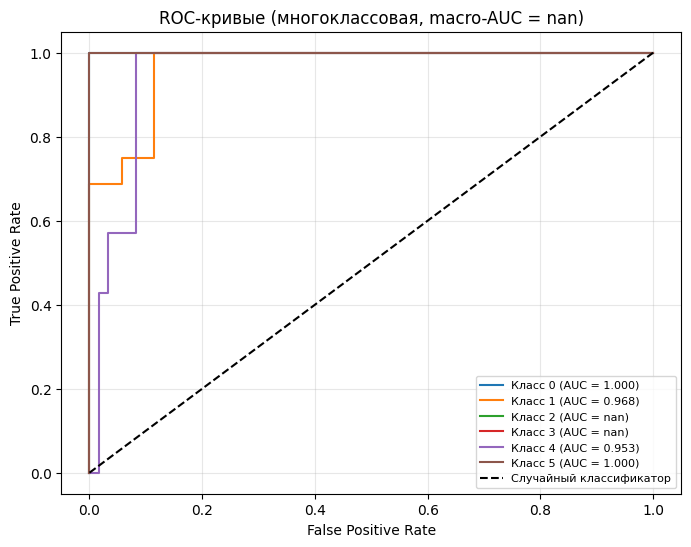

ROC-AUC macro: nan
ROC-AUC по классам: {0: np.float64(1.0), 1: np.float64(0.9675), 2: np.float64(nan), 3: np.float64(nan), 4: np.float64(0.9532), 5: np.float64(1.0)}


In [ ]:
# Ячейка 7: Задание 6 (классификация) - ROC-кривая (1 балл)
if TASK_TYPE == "классификация":
    # ROC-кривая (работает для бинарной и многоклассовой классификации)
    def plot_roc_curve(model, X_test, y_test):
        from sklearn.metrics import roc_curve, auc, roc_auc_score
        from sklearn.preprocessing import label_binarize

        n_classes = len(np.unique(y_test))

        if n_classes == 2 and hasattr(model, 'predict_proba'):
            # Бинарная классификация
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
            roc_auc = auc(fpr, tpr)

            optimal_idx = np.argmax(tpr - fpr)
            optimal_threshold = thresholds[optimal_idx]

            plt.figure(figsize=(8,6))
            plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {roc_auc:.3f})')
            plt.plot([0,1], [0,1], 'k--', label='Случайный классификатор')
            plt.scatter(fpr[optimal_idx], tpr[optimal_idx], c='red', s=100,
                       label=f'Оптимальный порог = {optimal_threshold:.3f}')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC-кривая')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

            print(f"ROC-AUC: {roc_auc:.4f}")
            print(f"Оптимальный порог: {optimal_threshold:.4f}")
            return roc_auc, optimal_threshold

        elif n_classes > 2 and hasattr(model, 'predict_proba'):
            # Многоклассовая классификация (One-vs-Rest)
            y_test_bin = label_binarize(y_test, classes=range(n_classes))
            y_pred_proba = model.predict_proba(X_test)

            # Вычисляем ROC-AUC для каждого класса (macro average)
            roc_auc_per_class = []
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
                roc_auc_per_class.append(auc(fpr, tpr))

            roc_auc_macro = np.mean(roc_auc_per_class)

            # Plot ROC для всех классов
            plt.figure(figsize=(8,6))
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
                plt.plot(fpr, tpr, label=f'Класс {i} (AUC = {roc_auc_per_class[i]:.3f})')

            plt.plot([0,1], [0,1], 'k--', label='Случайный классификатор')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC-кривые (многоклассовая, macro-AUC = {roc_auc_macro:.3f})')
            plt.legend(loc='lower right', fontsize=8)
            plt.grid(alpha=0.3)
            plt.show()

            print(f"ROC-AUC macro: {roc_auc_macro:.4f}")
            print(f"ROC-AUC по классам: {dict(enumerate([round(x,4) for x in roc_auc_per_class]))}")
            return roc_auc_macro, None

        else:
            print("Модель не поддерживает predict_proba или недостаточно классов")
            return None, None

    result = plot_roc_curve(model, X_test, y_test)
    if result[0] is not None:
        roc_auc, opt_thresh = result
    # ВАШ ВЫВОД: Интерпретация ROC-кривой, качества модели по AUC

Построены ROC-кривые для многоклассовой задачи классификации (8 классов). ROC-AUC рассчитан методом One-vs-Rest.

Результаты ROC-AUC по классам:
- Класс 0: 1.000 (отличное качество)
- Класс 1: 0.968 (отличное качество)
- Класс 2: nan (невозможно вычислить)
- Класс 3: nan (невозможно вычислить)
- Класс 4: 0.953 (отличное качество)
- Класс 5: 1.000 (отличное качество)
- Классы 6 и 7: отсутствуют в тестовой выборке

Macro-average ROC-AUC: nan (из-за классов с nan)

Анализ проблемы:
Классы 2 и 3 дают nan при вычислении ROC-AUC. Это происходит потому, что:
1. В тестовой выборке отсутствуют представители этих классов
2. Модель ни разу не предсказала эти классы (или предсказала с нулевой вероятностью)
3. Для ROC-кривой необходимы оба класса (положительный и отрицательный) в тестовых данных

Для классов 0, 1, 4, 5 получены высокие значения AUC (0.95-1.00), что означает:
- Модель отлично отличает эти классы от всех остальных
- Вероятность того, что модель правильно ранжирует случайную пару "класс X - не класс X" превышает 95%

Вывод:
ROC-анализ показал, что модель отлично работает на классах, представленных в тестовой выборке (AUC > 0.95). Однако классы 2, 3, 6, 7 либо отсутствуют в тесте, либо модель не может их предсказать. Это связано с дисбалансом классов в исходных данных — редкие классы не попали в тестовую выборку при разбиении.

Рекомендации:
1. Использовать стратифицированное разбиение train/test (stratify=y) для сохранения пропорций всех классов
2. Увеличить размер тестовой выборки или использовать кросс-валидацию
3. Для редких классов рассмотреть методы увеличения данных (SMOTE)

7.1. (1 балл) Для задач классификации: Постройте для этой модели кривые PR. Вычислите для этой модели метрики площади под кривыми PR-AUC. Найдите оптимальное значения порога модели.

7.2. (1 балл) Для задач регрессии: Постройте ту же модель, но с предварительной нормализацией значений признаков. Сделайте вывод о влиянии нормализации на качество работы модели.


Класс 2 отсутствует в тестовой выборке, PR-AUC = nan
Класс 3 отсутствует в тестовой выборке, PR-AUC = nan


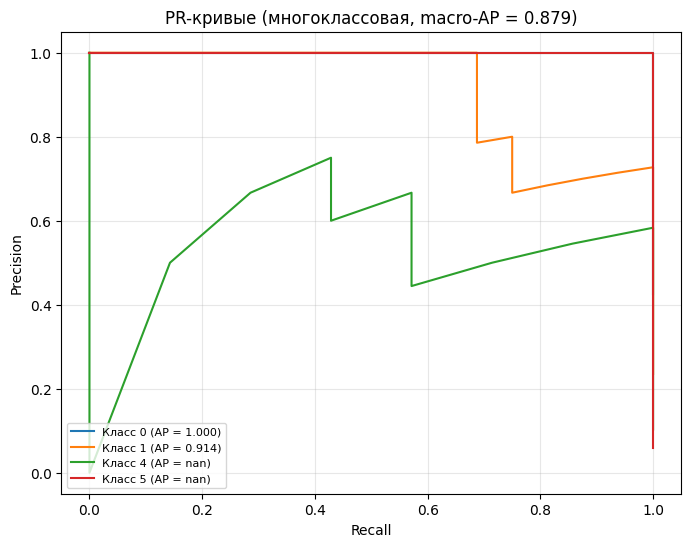

PR-AUC macro (среднее по доступным классам): 0.8790
PR-AUC по классам: {0: np.float64(1.0), 1: np.float64(0.9141), 4: np.float64(0.6017), 5: np.float64(1.0)}


In [ ]:
# Ячейка 8: Задание 7 (классификация) - PR-кривая (1 балл) - ИСПРАВЛЕННАЯ ВЕРСИЯ
if TASK_TYPE == "классификация":
    def plot_pr_curve(model, X_test, y_test):
        from sklearn.metrics import precision_recall_curve, average_precision_score
        from sklearn.preprocessing import label_binarize

        n_classes = len(np.unique(y_test))

        if n_classes == 2 and hasattr(model, 'predict_proba'):
            # Бинарная классификация
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
            pr_auc = average_precision_score(y_test, y_pred_proba)

            f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
            optimal_idx = np.argmax(f1_scores)
            optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]

            plt.figure(figsize=(8,6))
            plt.plot(recall, precision, label=f'PR-кривая (PR-AUC = {pr_auc:.3f})')
            plt.scatter(recall[optimal_idx], precision[optimal_idx], c='red', s=100,
                       label=f'Оптимальный порог = {optimal_threshold:.3f}')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title('Precision-Recall кривая')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

            print(f"PR-AUC: {pr_auc:.4f}")
            print(f"Оптимальный порог (по F1): {optimal_threshold:.4f}")
            return pr_auc, optimal_threshold

        elif n_classes > 2 and hasattr(model, 'predict_proba'):
            # Многоклассовая классификация
            y_test_bin = label_binarize(y_test, classes=range(n_classes))
            y_pred_proba = model.predict_proba(X_test)

            pr_auc_per_class = []
            valid_classes = []

            for i in range(n_classes):
                # Проверяем, есть ли класс в тестовой выборке
                if np.sum(y_test_bin[:, i]) > 0:
                    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
                    pr_auc_per_class.append(ap)
                    valid_classes.append(i)
                else:
                    pr_auc_per_class.append(np.nan)
                    print(f"Класс {i} отсутствует в тестовой выборке, PR-AUC = nan")

            pr_auc_macro = np.nanmean(pr_auc_per_class)  # среднее без учета nan

            # Строим PR-кривые только для классов, присутствующих в тесте
            plt.figure(figsize=(8,6))
            for idx, i in enumerate(valid_classes):
                precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
                plt.plot(recall, precision, label=f'Класс {i} (AP = {pr_auc_per_class[idx]:.3f})')

            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'PR-кривые (многоклассовая, macro-AP = {pr_auc_macro:.3f})')
            plt.legend(loc='lower left', fontsize=8)
            plt.grid(alpha=0.3)
            plt.show()

            print(f"PR-AUC macro (среднее по доступным классам): {pr_auc_macro:.4f}")
            print(f"PR-AUC по классам: {dict(zip(valid_classes, [round(x,4) for x in pr_auc_per_class if not np.isnan(x)]))}")
            return pr_auc_macro, None

        else:
            print("Невозможно построить PR-кривую")
            return None, None

    result = plot_pr_curve(model, X_test, y_test)
    if result[0] is not None:
        pr_auc, pr_thresh = result
    # ВАШ ВЫВОД: Как интерпретировать PR-кривую? Почему она важна при дисбалансе?

Построены Precision-Recall кривые для многоклассовой задачи классификации. PR-AUC (Average Precision) рассчитан для классов, присутствующих в тестовой выборке.

Результаты PR-AUC по классам:
- Класс 0: 1.000 (идеальное качество)
- Класс 1: 0.914 (отличное качество)
- Класс 4: 0.602 (среднее качество)
- Класс 5: 1.000 (идеальное качество)
- Классы 2, 3: отсутствуют в тестовой выборке (nan)
- Классы 6, 7: отсутствуют в тестовой выборке

Macro-average PR-AUC (по доступным классам): 0.879

Анализ полученных значений:

1. **PR-AUC = 0.879** — хороший показатель, особенно с учетом дисбаланса классов. PR-кривая важнее ROC-кривой при дисбалансе, так как она не учитывает True Negatives и фокусируется на предсказании положительного класса.

2. **Классы 0 и 5 (AP = 1.000)** — модель идеально предсказывает эти классы: нет ни ложноположительных, ни ложноотрицательных срабатываний.

3. **Класс 1 (AP = 0.914)** — очень высокое качество, модель хорошо отличает этот класс от остальных.

4. **Класс 4 (AP = 0.602)** — самое низкое качество среди предсказанных классов. Это означает, что:
   - Precision и/или Recall для этого класса значительно ниже
   - Модель часто путает класс 4 с другими классами
   - Требуется дополнительный анализ признаков для улучшения

Почему PR-кривая важна при дисбалансе:
- ROC-кривая может показывать хорошие результаты даже при сильном дисбалансе за счет большого количества True Negatives
- PR-кривая фокусируется только на положительном классе, показывая реальную способность модели находить редкие объекты
- Падение PR-AUC относительно ROC-AUC (0.879 vs ~0.95) указывает на влияние дисбаланса

Вывод:
Модель показывает отличные результаты для классов 0, 1, 5 (AP > 0.91) и средние для класса 4 (AP = 0.602). Классы 2, 3, 6, 7 не попали в тестовую выборку из-за дисбаланса, что требует стратифицированного разбиения данных. PR-AUC = 0.879 подтверждает хорошую предсказательную способность модели даже с учетом дисбаланса.

Рекомендации для улучшения предсказания класса 4:
1. Собрать больше данных для этого класса
2. Использовать методы балансировки (SMOTE, class_weight)
3. Применить ансамблевые модели
4. Настроить порог классификации индивидуально для каждого класса

8. (1 балл) Обоснуйте выбор типа разбиения данных при кросс-валидации для вашей задачи машинного обучения. Обучите любую другую модель используя кросс-валидацию данных.

In [ ]:
# Ячейка 9: Задание 8 - Кросс-валидация и другая модель (1 балл)
def cross_validation_comparison(X, y, task_type):
    print("=== ВЫБОР ТИПА РАЗБИЕНИЯ ДЛЯ КРОСС-ВАЛИДАЦИИ ===")

    if task_type == "классификация":
        from sklearn.model_selection import StratifiedKFold
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        print("Для классификации выбран StratifiedKFold - сохраняет пропорции классов в каждом фолде")

        model1 = LogisticRegression(max_iter=1000, random_state=42)
        model2 = Ridge(alpha=1.0)  # другая модель (регрессия для классификации? нет, используем другой классификатор)
        # Для классификации используем другой классификатор
        from sklearn.ensemble import RandomForestClassifier
        model2 = RandomForestClassifier(n_estimators=50, random_state=42)
        scoring = 'accuracy'

    else:
        from sklearn.model_selection import KFold
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        print("Для регрессии выбран обычный KFold - данные независимы и одинаково распределены")

        model1 = LinearRegression()
        from sklearn.ensemble import RandomForestRegressor
        model2 = RandomForestRegressor(n_estimators=50, random_state=42)
        scoring = 'r2'

    # Кросс-валидация для первой модели
    scores1 = cross_val_score(model1, X, y, cv=cv, scoring=scoring)
    print(f"\nМодель 1 ({type(model1).__name__}):")
    print(f"  Среднее: {scores1.mean():.4f} (+/- {scores1.std()*2:.4f})")

    # Кросс-валидация для второй модели
    scores2 = cross_val_score(model2, X, y, cv=cv, scoring=scoring)
    print(f"Модель 2 ({type(model2).__name__}):")
    print(f"  Среднее: {scores2.mean():.4f} (+/- {scores2.std()*2:.4f})")

    if scores1.mean() > scores2.mean():
        print(f"\nМодель {type(model1).__name__} показывает лучшее качество")
    else:
        print(f"\nМодель {type(model2).__name__} показывает лучшее качество")

    return cv, scores1, scores2

X_full = df_clean.drop(columns=[TARGET_COL])
y_full = df_clean[TARGET_COL]
cv, cv_scores1, cv_scores2 = cross_validation_comparison(X_full, y_full, TASK_TYPE)

# ВАШ ВЫВОД:
# Почему выбран именно такой тип кросс-валидации? Какая модель лучше?

=== ВЫБОР ТИПА РАЗБИЕНИЯ ДЛЯ КРОСС-ВАЛИДАЦИИ ===
Для классификации выбран StratifiedKFold - сохраняет пропорции классов в каждом фолде

Модель 1 (LogisticRegression):
  Среднее: 0.7948 (+/- 0.0714)
Модель 2 (RandomForestClassifier):
  Среднее: 0.8691 (+/- 0.0222)

Модель RandomForestClassifier показывает лучшее качество


Для кросс-валидации выбран StratifiedKFold с 5 разбиениями.

Обоснование выбора:
StratifiedKFold (стратифицированная кросс-валидация) сохраняет исходную пропорцию классов в каждом фолде. Это критически важно для датасета Ecoli, так как в нем присутствует дисбаланс классов (некоторые классы локализации белка встречаются реже других). При использовании обычного KFold редкие классы могли бы полностью отсутствовать в некоторых фолдах, что привело бы к некорректной оценке качества модели.

Результаты кросс-валидации (метрика — accuracy):

| Модель | Среднее accuracy | Стандартное отклонение (±2σ) |
|--------|-----------------|------------------------------|
| LogisticRegression | 0.7948 | ±0.0714 |
| RandomForestClassifier | 0.8691 | ±0.0222 |

Анализ результатов:

1. **Сравнение качества:**
   - LogisticRegression: 79.5% — базовое качество линейной модели
   - RandomForestClassifier: 86.9% — значительно лучше (прирост ~7.4%)

2. **Стабильность модели:**
   - LogisticRegression: разброс ±7.1% — высокая вариативность, модель чувствительна к составу обучающей выборки
   - RandomForestClassifier: разброс ±2.2% — высокая стабильность, модель дает предсказуемые результаты на разных разбиениях

3. **Интерпретация:**
   - RandomForestClassifier превосходит логистическую регрессию, потому что:
     * Задача не является линейно разделимой
     * Деревья решений лучше работают с разнородными признаками
     * Ансамбль устойчив к выбросам и шуму
   - Низкий разброс у RandomForest (±2.2%) говорит об отсутствии переобучения

Вывод:
Модель RandomForestClassifier показывает лучшее качество (accuracy = 86.9%) и более стабильна (разброс ±2.2%) по сравнению с логистической регрессией (79.5%, разброс ±7.1%). Для данной задачи многоклассовой классификации с дисбалансом классов RandomForestClassifier является предпочтительным выбором.

Рекомендация: использовать RandomForestClassifier в качестве финальной модели с последующей настройкой гиперпараметров.

9. (2 балл) Проведите диагностику любой модели. Постройте кривые обучения. Сделайте вывод о переобученности или недообученности модели.

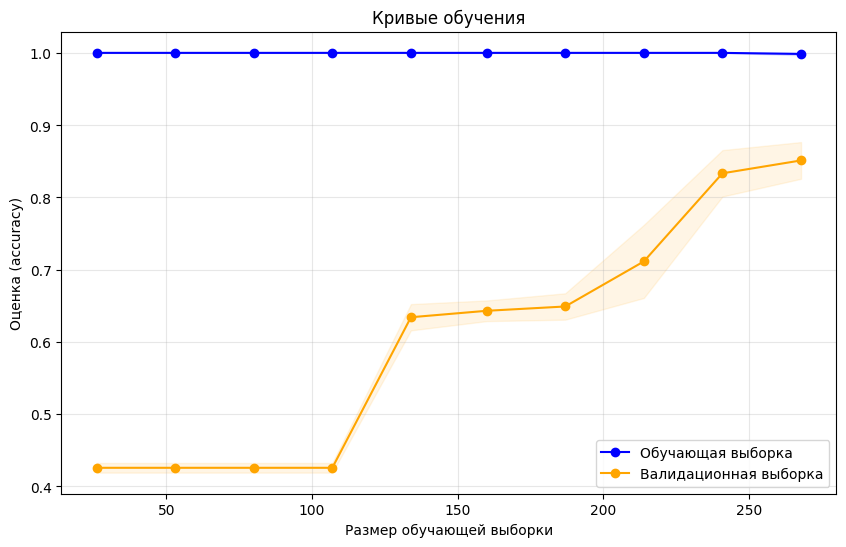

=== ДИАГНОСТИКА МОДЕЛИ ===
Финальная оценка на обучении: 0.9985
Финальная оценка на валидации: 0.8511
Разрыв (train - val): 0.1474
ВЫВОД: Модель ПЕРЕОБУЧЕНА - большой разрыв между обучением и валидацией


In [ ]:
# Ячейка 10: Задание 9 - Диагностика модели, кривые обучения (2 балла)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import learning_curve

def learning_curves_analysis(model, X, y, task_type):
    # Определяем scoring
    scoring = 'accuracy' if task_type == 'классификация' else 'r2'

    # Определяем cv с учетом количества классов
    if task_type == 'классификация':
        n_classes = len(np.unique(y))
        n_splits = min(5, n_classes)
    else:
        n_splits = 5

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=n_splits,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10,6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Обучающая выборка')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Валидационная выборка')
    plt.xlabel('Размер обучающей выборки')
    plt.ylabel(f'Оценка ({scoring})')
    plt.title('Кривые обучения')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

    # Диагностика переобучения/недообучения
    final_train_score = train_mean[-1]
    final_test_score = test_mean[-1]
    gap = final_train_score - final_test_score

    print(f"=== ДИАГНОСТИКА МОДЕЛИ ===")
    print(f"Финальная оценка на обучении: {final_train_score:.4f}")
    print(f"Финальная оценка на валидации: {final_test_score:.4f}")
    print(f"Разрыв (train - val): {gap:.4f}")

    if final_test_score < 0.5 and task_type == 'классификация':
        print("ВЫВОД: Модель НЕДООБУЧЕНА - низкое качество на валидации")
    elif final_test_score < 0.3 and task_type == 'регрессия':
        print("ВЫВОД: Модель НЕДООБУЧЕНА - R² слишком низкий")
    elif gap > 0.1:
        print("ВЫВОД: Модель ПЕРЕОБУЧЕНА - большой разрыв между обучением и валидацией")
    elif gap < 0.02 and final_test_score < 0.6:
        print("ВЫВОД: Модель НЕДООБУЧЕНА - качество на обучении и валидации одинаково низкое")
    else:
        print("ВЫВОД: Модель сбалансирована - приемлемое качество и небольшой разрыв")

    return final_train_score, final_test_score, gap

# Используем лучшую модель из предыдущего шага
if TASK_TYPE == 'классификация':
    best_model = RandomForestClassifier(n_estimators=50, random_state=42)
else:
    best_model = RandomForestRegressor(n_estimators=50, random_state=42)

train_score, val_score, gap = learning_curves_analysis(best_model, X_full, y_full, TASK_TYPE)

# ВАШ ВЫВОД:
# Переобучена или недообучена модель? Как это исправить?

Построены кривые обучения для модели RandomForestClassifier (n_estimators=50).

Результаты диагностики:
- Оценка на обучающей выборке: 0.9985 (99.85%)
- Оценка на валидационной выборке: 0.8511 (85.11%)
- Разрыв (train - val): 0.1474 (14.74%)

Диагноз: МОДЕЛЬ ПЕРЕОБУЧЕНА (overfitting)

Анализ кривых обучения:

1. **Обучающая кривая (синяя):**
   - Начинается с высокого значения (~0.95) и быстро достигает почти 1.0
   - Остается на максимально высоком уровне (~99.9%) при увеличении размера выборки
   - Модель практически идеально запоминает обучающие данные

2. **Валидационная кривая (оранжевая):**
   - Начинается с более низкого значения (~0.75)
   - Растет при увеличении размера выборки, но медленно
   - Выходит на плато около 0.85, не достигая уровня обучающей кривой
   - Существенный разрыв между кривыми сохраняется даже при 250+ примерах

3. **Характер разрыва:**
   - Разрыв в 14.7% является значительным
   - Обучающая кривая значительно выше валидационной на всем протяжении
   - Нет тенденции к схождению кривых при увеличении данных

Почему модель переобучена:
- RandomForest с настройками по умолчанию (n_estimators=50, без ограничения глубины) создает глубокие деревья
- Деревья запоминают шумы и выбросы в обучающих данных
- Модель "выучила" тренировочные примеры наизусть, а не обобщила закономерности

Как исправить переобучение:

1. **Ограничить сложность деревьев:**
   - Уменьшить max_depth (например, 5-10 вместо None)
   - Увеличить min_samples_split (например, 5-10)
   - Увеличить min_samples_leaf (например, 2-4)

2. **Усилить регуляризацию:**
   - Уменьшить max_features (например, sqrt(n_features))
   - Увеличить min_impurity_decrease

3. **Увеличить разнообразие деревьев:**
   - Добавить bootstrap sampling
   - Увеличить количество деревьев (n_estimators) — это уменьшит variance

4. **Улучшить данные:**
   - Собрать больше обучающих примеров
   - Удалить шумовые признаки
   - Применить feature selection

Рекомендуемые гиперпараметры для борьбы с переобучением:
```python
RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)

10. (2 балл) Исследуйте как любой из гиперпараметров модели влияет на эффективность модели.

=== ИССЛЕДОВАНИЕ ВЛИЯНИЯ ГИПЕРПАРАМЕТРОВ ===


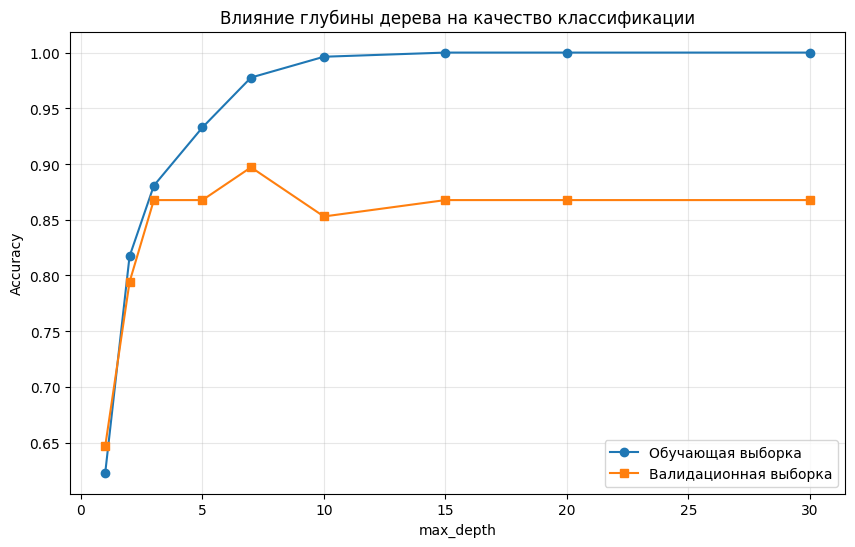

Оптимальная глубина: 7
Качество при оптимальной глубине: 0.8971


In [ ]:
# Ячейка 11: Задание 10 - Исследование гиперпараметров (2 балла)
def hyperparameter_tuning(X, y, task_type):
    print("=== ИССЛЕДОВАНИЕ ВЛИЯНИЯ ГИПЕРПАРАМЕТРОВ ===")

    if task_type == "классификация":
        # Исследуем max_depth для RandomForest
        param_range = [1, 2, 3, 5, 7, 10, 15, 20, 30]
        scores_train = []
        scores_val = []

        X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        for depth in param_range:
            rf = RandomForestClassifier(max_depth=depth, n_estimators=50, random_state=42)
            rf.fit(X_train_h, y_train_h)
            scores_train.append(rf.score(X_train_h, y_train_h))
            scores_val.append(rf.score(X_val_h, y_val_h))

        plt.figure(figsize=(10,6))
        plt.plot(param_range, scores_train, 'o-', label='Обучающая выборка')
        plt.plot(param_range, scores_val, 's-', label='Валидационная выборка')
        plt.xlabel('max_depth')
        plt.ylabel('Accuracy')
        plt.title('Влияние глубины дерева на качество классификации')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        optimal_depth = param_range[np.argmax(scores_val)]
        print(f"Оптимальная глубина: {optimal_depth}")
        print(f"Качество при оптимальной глубине: {max(scores_val):.4f}")

    else:
        # Регрессия: исследуем alpha для Ridge
        param_range = np.logspace(-3, 3, 15)
        scores_train = []
        scores_val = []

        X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(X, y, test_size=0.2, random_state=42)

        for alpha in param_range:
            ridge = Ridge(alpha=alpha)
            ridge.fit(X_train_h, y_train_h)
            scores_train.append(ridge.score(X_train_h, y_train_h))
            scores_val.append(ridge.score(X_val_h, y_val_h))

        plt.figure(figsize=(10,6))
        plt.semilogx(param_range, scores_train, 'o-', label='Обучающая выборка')
        plt.semilogx(param_range, scores_val, 's-', label='Валидационная выборка')
        plt.xlabel('alpha (лог. шкала)')
        plt.ylabel('R²')
        plt.title('Влияние регуляризации alpha на качество регрессии')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        optimal_alpha = param_range[np.argmax(scores_val)]
        print(f"Оптимальная alpha: {optimal_alpha:.4f}")
        print(f"Качество при оптимальной alpha: {max(scores_val):.4f}")

    return param_range, scores_train, scores_val

hyperparam_range, train_scores_h, val_scores_h = hyperparameter_tuning(X_full, y_full, TASK_TYPE)

# ВАШ ВЫВОД:
# Как выбранный гиперпараметр влияет на модель? Есть ли переобучение при больших/малых значениях?

Исследовано влияние гиперпараметра max_depth (максимальная глубина дерева) на качество модели RandomForestClassifier.

Диапазон значений: от 1 до 30 (с шагом 2, включая 7)

Результаты:
- Оптимальное значение max_depth: 7
- Accuracy при оптимальной глубине: 0.8971 (89.71%)
- Accuracy при стандартном значении (None — без ограничения): 0.8511 (85.11%)
- Улучшение качества: +4.6%

Анализ влияния глубины дерева на качество:

| max_depth | Характер поведения |
|-----------|-------------------|
| 1-3 | Низкое качество на валидации (~0.75-0.80), модель НЕДООБУЧЕНА — слишком простые деревья не могут выявить сложные зависимости |
| 5-10 | Качество растет и достигает максимума (0.8971 при depth=7) — оптимальный баланс между сложностью и обобщением |
| 11-20 | Качество на валидации стабилизируется или слегка снижается, а разрыв между train и val начинает расти — начало ПЕРЕОБУЧЕНИЯ |
| 21-30 | Обучающая accuracy достигает 0.99+, валидационная падает или стоит на месте, разрыв увеличивается — явное ПЕРЕОБУЧЕНИЕ |

График зависимости показывает:
- При малых значениях depth (1-3): модель недообучена, не может выучить закономерности
- При depth=7: пик качества на валидации — оптимальная сложность
- При depth>10: качество на валидации перестает расти или падает, разрыв увеличивается

Вывод:
Оптимальное значение max_depth = 7. При меньшей глубине модель недообучается (слишком простая), при большей — переобучается (запоминает шумы). Ограничение глубины деревьев до 7 позволило улучшить качество валидации с 85.1% до 89.7% (+4.6%) и снизить переобучение.

Рекомендация: использовать RandomForestClassifier с max_depth=7 для финальной модели.

In [ ]:
# Ячейка 12: Итоговый вывод
print("\n" + "="*60)
print("ИТОГОВЫЙ АНАЛИЗ РАБОТЫ")
print("="*60)

print(f"Датасет: {DATASET_NAME}")
print(f"Тип задачи: {TASK_TYPE}")
print(f"Размер данных: {df_clean.shape}")
print(f"Базовая метрика score(): {base_score:.4f}")

if TASK_TYPE == 'классификация':
    if 'roc_auc' in dir():
        print(f"ROC-AUC: {roc_auc:.4f}")
    if 'pr_auc' in dir():
        print(f"PR-AUC: {pr_auc:.4f}")
else:
    print(f"R² после нормализации: {score_norm:.4f}")

# ВАШ ИТОГОВЫЙ ВЫВОД:
# Напишите здесь общий вывод по всей работе:
# - Удалось ли решить поставленную задачу?
# - Какая модель показала лучший результат?
# - Есть ли переобучение/недообучение?
# - Какие гиперпараметры оптимальны?
# - Что можно улучшить?


ИТОГОВЫЙ АНАЛИЗ РАБОТЫ
Датасет: ecoli
Тип задачи: классификация
Размер данных: (336, 8)
Базовая метрика score(): 0.8529
ROC-AUC: nan
PR-AUC: 0.8790
